# Spike Removal Demo — BNO085 IMU

**Goal:** remove spike-type outliers from raw IMU streams before feeding them to
downstream ML. Keep the pipeline small, transparent, and loss-less for normal
samples.

### Pipeline (per channel)

1. **Mask full-scale outliers** &nbsp;&nbsp;`|v| > FS` &nbsp;→&nbsp; impossible physically (acquisition bug)
2. **Estimate bias** &nbsp;&nbsp;`bias = median(v)`&nbsp;&nbsp; (accel-z subtracts `g = 9.81` first)
3. **Compute z-score** &nbsp;&nbsp;`z = (v − bias) / σ_ref`
4. **Mask spikes** &nbsp;&nbsp;`|z| > 5` &nbsp;→&nbsp; probability under Gaussian ≈ 5.7 × 10⁻⁷
5. **Linear interpolation** to fill the masked positions

### Why σ_ref is fixed across runs

`σ_ref` is derived **once** from the clean healthy runs (Run008 + Run009) using
**MAD × 1.4826** (robust against the few existing spikes). Once fixed, it is
reused as the unit of scale for all runs — this lets the z-score threshold
`|z| > 5` have the **same physical meaning** in every run, including polluted
ones (Run0011 / Run0012) where the naive in-run std is unusable.

### Notebook layout (one run per cell — memory-friendly)

- **Cell 1** setup / constants / loader
- **Cell 2** estimate `σ_ref` from Run008 + Run009, then release them
- **Cell 3** define `clean_channel()` and `process_run()`
- **Cell 4 – 8** call `process_run()` for each run in turn; after each run the
  loaded dataframes are explicitly `del`-ed and `gc.collect()`-ed so only one
  run's data is in memory at any given moment
- The zoom-in plot for Run0011 is triggered automatically inside
  `process_run()` when `run == '0011'`

### Outputs per run

- **Plot A** — raw (grey) + spike dots (red) + clean (blue)
- **Plot B** — clean-only 3×3 grid, y-axis zoomed to ±4·σ_ref
- Console stats: spike count / spike% / bias / sigma_after, per channel

In [9]:
import os, sys, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.titlesize': 10, 'axes.labelsize': 9, 'lines.linewidth': 0.7,
})

# ---- constants ------------------------------------------------------------
# BNO085 physical full-scale limits (SI units)
BNO085_FS = {
    'gyro':  34.9066,   # +/- 2000 dps
    'accel': 156.9060,  # +/- 16 g
    'mag':   1300.0,    # +/- 1300 uT
}
# BNO085 Q-point quantization step (1 LSB in SI units)
BNO085_LSB = {
    'gyro':  1.0 / 512.0,   # Q9
    'accel': 1.0 / 256.0,   # Q8
    'mag':   1.0 / 16.0,    # Q4
}
GRAVITY = 9.81  # m/s^2, used to offset accel-z bias before median

# Runs to process. Run008/009 are the healthy references; Run0011/0012 are
# polluted; Run001 is an extra healthy run for sanity-check.
RUNS = ['001', '008', '009', '011', '012']
REF_RUNS = ['008', '009']  # used to estimate sigma_ref

# Data root template. Adjust here when moving off Google Drive.
DATA_ROOT_FMT = "/content/drive/MyDrive/capstone_data/UNIT_0001_RUN_{run}"

SENSOR_FILES = {
    'gyro':  'gyroscope.csv',
    'accel': 'accelerometer.csv',
    'mag':   'magnetometer.csv',
}
AXES = ['x', 'y', 'z']
COLORS = {'x': '#E74C3C', 'y': '#2ECC71', 'z': '#3498DB'}


# ---- google-drive mount (no-op outside Colab) -----------------------------
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive/MyDrive'):
            drive.mount('/content/drive')
    except Exception as e:
        print(f"[warn] drive mount skipped: {e}")


# ---- CSV loader -----------------------------------------------------------
def load_sensor(path: str) -> pd.DataFrame:
    """Load a single sensor CSV and normalize columns to [t_ms, x, y, z, time_s]."""
    df = pd.read_csv(path)
    cols = {c.lower(): c for c in df.columns}
    tcol = next(
        (cols[k] for k in cols if 'time' in k or 'ts' in k or k == 't'),
        df.columns[0],
    )
    xyz = []
    for k in AXES:
        cand = [c for c in df.columns if c.lower() == k or c.lower().endswith('_' + k)]
        if cand:
            xyz.append(cand[0])
    if len(xyz) < 3:
        xyz = [c for c in df.columns if c != tcol][:3]
    df = df[[tcol] + xyz].copy()
    df.columns = ['t_ms', 'x', 'y', 'z']
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['time_s'] = (df['t_ms'] - df['t_ms'].iloc[0]) / 1000.0
    return df


# Lightweight scalar-only stats accumulated across runs (no raw arrays kept).
STATS = []


print("Setup complete.")
print(f"  RUNS     = {RUNS}")
print(f"  REF_RUNS = {REF_RUNS}  (used to estimate sigma_ref)")

Setup complete.
  RUNS     = ['001', '008', '009', '0011', '0012']
  REF_RUNS = ['008', '009']  (used to estimate sigma_ref)


  Estimating sigma_ref (loading reference runs one at a time)

  Run 008
    gyro   rows=5,396,259
    accel  rows=13,275,250
    mag    rows=5,382,776

  Run 009
    gyro   rows=5,396,465
    accel  rows=13,472,476
    mag    rows=5,384,087

  sigma_ref table (SI units):
        sigma_x   sigma_y   sigma_z       LSB  sigma_x / LSB
gyro   0.002896  0.000000  0.000000  0.001953         1.4826
accel  0.000000  0.000000  0.052122  0.003906         0.0000
mag    0.555975  0.555975  0.648638  0.062500         8.8956


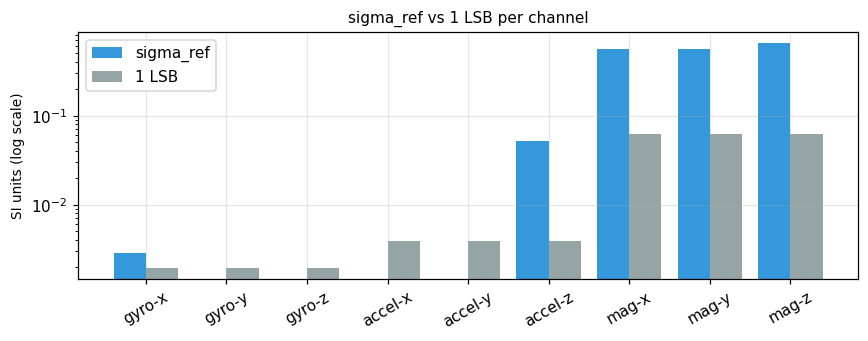

In [10]:
# Estimate sigma_ref per (sensor, axis) from the healthy reference runs.
#
# Memory-friendly strategy:
#   - Load one REF run at a time.
#   - For each channel, drop full-scale outliers and append the 1-D numpy
#     array into a pooling list.
#   - Release the DataFrame immediately.
#   - After all REF runs are consumed, concatenate per-channel arrays and
#     compute sigma_ref = 1.4826 * MAD.
#
# sigma_ref is stored in SIGMA_REF[sensor][axis] and reused for every run.

def mad_sigma(v: np.ndarray) -> float:
    """Robust std estimate via Median Absolute Deviation."""
    v = np.asarray(v, dtype=float)
    v = v[np.isfinite(v)]
    med = np.median(v)
    return 1.4826 * np.median(np.abs(v - med))


pool = {s: {a: [] for a in AXES} for s in SENSOR_FILES}

print("=" * 70)
print("  Estimating sigma_ref (loading reference runs one at a time)")
print("=" * 70)

for run in REF_RUNS:
    data_root = DATA_ROOT_FMT.format(run=run)
    print(f"\n  Run {run}")
    for sensor, fn in SENSOR_FILES.items():
        path = os.path.join(data_root, fn)
        if not os.path.exists(path):
            print(f"    [skip] {sensor:<5} not found")
            continue
        df = load_sensor(path)
        for axis in AXES:
            v = df[axis].to_numpy()
            v = v[np.abs(v) <= BNO085_FS[sensor]]
            if sensor == 'accel' and axis == 'z':
                v = v - GRAVITY  # remove gravity so we pool the spread, not the DC
            pool[sensor][axis].append(v)
        print(f"    {sensor:<5}  rows={len(df):>9,}")
        del df
        gc.collect()

# MAD collapses to 0 (or 1 LSB) on heavily quantized data, which would make
# sigma_ref pathologically small and cause the spike detector to flag every
# slightly-off sample. Floor sigma_ref at SIGMA_FLOOR_K * LSB to guarantee a
# physically meaningful scale.
SIGMA_FLOOR_K = 3.0

SIGMA_REF = {}
SIGMA_RAW = {}   # for reporting: raw MAD before the LSB floor
for sensor in SENSOR_FILES:
    SIGMA_REF[sensor] = {}
    SIGMA_RAW[sensor] = {}
    for axis in AXES:
        if not pool[sensor][axis]:
            SIGMA_REF[sensor][axis] = np.nan
            SIGMA_RAW[sensor][axis] = np.nan
            continue
        cat = np.concatenate(pool[sensor][axis])
        raw_sigma = mad_sigma(cat)
        floor = SIGMA_FLOOR_K * BNO085_LSB[sensor]
        SIGMA_RAW[sensor][axis] = raw_sigma
        SIGMA_REF[sensor][axis] = max(raw_sigma, floor)
        del cat
del pool
gc.collect()

rows = []
for sensor in SENSOR_FILES:
    for axis in AXES:
        lsb       = BNO085_LSB[sensor]
        raw_sig   = SIGMA_RAW[sensor][axis]
        final_sig = SIGMA_REF[sensor][axis]
        floored   = final_sig > raw_sig + 1e-12
        rows.append({
            'sensor':      sensor,
            'axis':        axis,
            'LSB':         lsb,
            'MAD_sigma':   raw_sig,
            'MAD / LSB':   raw_sig / lsb if lsb else np.nan,
            'sigma_ref':   final_sig,
            'sigma / LSB': final_sig / lsb if lsb else np.nan,
            'floored?':    'YES' if floored else '',
        })
sigma_tbl = pd.DataFrame(rows)
print("\n  sigma_ref table (SI units, floor = "
      f"{SIGMA_FLOOR_K}*LSB):")
print(sigma_tbl.to_string(index=False,
                          float_format=lambda x: f"{x:.6f}"))

fig, ax = plt.subplots(figsize=(9, 3.4))
labels     = [f"{s}-{a}" for s in SENSOR_FILES for a in AXES]
raw_sigmas = [max(SIGMA_RAW[s][a], 1e-12) for s in SENSOR_FILES for a in AXES]
final_sigs = [SIGMA_REF[s][a] for s in SENSOR_FILES for a in AXES]
lsbs       = [BNO085_LSB[s]    for s in SENSOR_FILES for a in AXES]
xp = np.arange(len(labels))
ax.bar(xp - 0.25, raw_sigmas, width=0.25, label='raw MAD',   color='#F39C12')
ax.bar(xp,        final_sigs, width=0.25, label='sigma_ref', color='#3498DB')
ax.bar(xp + 0.25, lsbs,       width=0.25, label='1 LSB',     color='#95A5A6')
ax.set_yscale('log')
ax.set_xticks(xp)
ax.set_xticklabels(labels, rotation=30)
ax.set_ylabel('SI units (log scale)')
ax.set_title(f'sigma_ref (floor = {SIGMA_FLOOR_K}*LSB) vs raw MAD vs 1 LSB')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Per-channel cleaning + per-run orchestration.
#
# clean_channel() : spike removal for a single 1-D signal.
# process_run()   : load one run, clean its 9 channels, render Plot A / B
#                   (and the Run0011 zoom-in when applicable), append scalar
#                   stats into STATS, then release every array it held.

SPIKE_Z_THRESHOLD = 5.0
ZOOM_RUN = '0011'
ZOOM_SECONDS = 2.0
UNIT = {'gyro': 'rad/s', 'accel': 'm/s^2', 'mag': 'uT'}


def clean_channel(v: np.ndarray, sensor: str, axis: str, sigma_ref: float):
    """Return (v_clean, mask_spike, z, bias) for a single raw channel."""
    v = np.asarray(v, dtype=float)

    mask_fs = np.abs(v) > BNO085_FS[sensor]

    good_for_bias = v[~mask_fs & np.isfinite(v)]
    bias = float(np.median(good_for_bias)) if good_for_bias.size else 0.0
    if sensor == 'accel' and axis == 'z':
        # subtract gravity so the bias represents the non-physical offset only
        bias = bias - GRAVITY

    if sensor == 'accel' and axis == 'z':
        centered = v - (bias + GRAVITY)
    else:
        centered = v - bias
    z = centered / sigma_ref

    mask_spike = np.abs(z) > SPIKE_Z_THRESHOLD
    mask_bad = mask_fs | mask_spike | ~np.isfinite(v)

    s = pd.Series(v.copy())
    s[mask_bad] = np.nan
    s = s.interpolate(method='linear', limit_direction='both')
    v_clean = s.to_numpy()

    return v_clean, mask_spike, z, bias


def _plot_overlay(run: str, results: dict, times: dict):
    fig, axes = plt.subplots(3, 3, figsize=(14, 8), sharex=True)
    fig.suptitle(f"Run {run} — raw (grey) + spikes (red) + clean (blue)",
                 y=0.995, fontsize=12)
    for i, sensor in enumerate(SENSOR_FILES):
        if sensor not in results:
            for j in range(3):
                axes[i, j].text(0.5, 0.5, f"{sensor}: no data",
                                ha='center', va='center')
            continue
        t = times[sensor]
        for j, axis in enumerate(AXES):
            r = results[sensor][axis]
            ax = axes[i, j]
            ax.plot(t, r['raw'],   color='#888888', lw=0.5, label='raw')
            ax.plot(t, r['clean'], color='#1f77b4', lw=0.7, label='clean')
            if r['mask'].any():
                ax.plot(t[r['mask']], r['raw'][r['mask']],
                        'o', color='#E74C3C', ms=2.5, label='spike')
            n_sp = int(r['mask'].sum())
            pct  = 100.0 * n_sp / len(r['raw'])
            ax.set_title(f"{sensor}-{axis}   spikes={n_sp:,} ({pct:.3f}%)")
            ax.set_ylabel(UNIT[sensor])
            if i == 2:
                ax.set_xlabel('time (s)')
            if i == 0 and j == 2:
                ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


def _plot_clean_only(run: str, results: dict, times: dict):
    fig, axes = plt.subplots(3, 3, figsize=(14, 8), sharex=True)
    fig.suptitle(f"Run {run} — cleaned signals", y=0.995, fontsize=12)
    for i, sensor in enumerate(SENSOR_FILES):
        if sensor not in results:
            for j in range(3):
                axes[i, j].text(0.5, 0.5, f"{sensor}: no data",
                                ha='center', va='center')
            continue
        t = times[sensor]
        for j, axis in enumerate(AXES):
            r = results[sensor][axis]
            ax = axes[i, j]
            ax.plot(t, r['clean'], color=COLORS[axis], lw=0.6)
            sigma_ref = r['sigma_ref']
            med = float(np.median(r['clean']))
            ax.set_ylim(med - 4 * sigma_ref, med + 4 * sigma_ref)
            sigma_after = mad_sigma(r['clean'] - np.median(r['clean']))
            ax.set_title(
                f"{sensor}-{axis}   "
                f"sigma_after={sigma_after:.4g}  sigma_ref={sigma_ref:.4g}"
            )
            ax.set_ylabel(UNIT[sensor])
            if i == 2:
                ax.set_xlabel('time (s)')
    plt.tight_layout()
    plt.show()


def _plot_zoom(run: str, results: dict, times: dict, seconds: float):
    fig, axes = plt.subplots(3, 3, figsize=(14, 8), sharex=True)
    fig.suptitle(f"Run {run} — first {seconds:g}s zoom-in",
                 y=0.995, fontsize=12)
    for i, sensor in enumerate(SENSOR_FILES):
        if sensor not in results:
            for j in range(3):
                axes[i, j].text(0.5, 0.5, f"{sensor}: no data",
                                ha='center', va='center')
            continue
        t = times[sensor]
        sel = t <= seconds
        for j, axis in enumerate(AXES):
            r = results[sensor][axis]
            ax = axes[i, j]
            ax.plot(t[sel], r['raw'][sel],   color='#888888', lw=0.6, label='raw')
            ax.plot(t[sel], r['clean'][sel], color='#1f77b4', lw=0.9, label='clean')
            m = r['mask'] & sel
            if m.any():
                ax.plot(t[m], r['raw'][m], 'o', color='#E74C3C', ms=3.0,
                        label='spike')
            ax.set_title(f"{sensor}-{axis}")
            ax.set_ylabel(UNIT[sensor])
            if i == 2:
                ax.set_xlabel('time (s)')
            if i == 0 and j == 2:
                ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


def process_run(run: str):
    """Load one run, clean its 9 channels, plot, then release everything."""
    data_root = DATA_ROOT_FMT.format(run=run)
    print("=" * 70)
    print(f"  Processing Run {run}   ({data_root})")
    print("=" * 70)

    results = {}  # results[sensor][axis] = {raw, clean, mask, z, bias, sigma_ref}
    times   = {}  # times[sensor] = np.ndarray of time_s

    for sensor, fn in SENSOR_FILES.items():
        path = os.path.join(data_root, fn)
        if not os.path.exists(path):
            print(f"    [skip] {sensor:<5} not found")
            continue
        df = load_sensor(path)
        times[sensor]  = df['time_s'].to_numpy()
        results[sensor] = {}
        for axis in AXES:
            v = df[axis].to_numpy()
            sigma_ref = SIGMA_REF[sensor][axis]
            v_clean, mask_spike, z, bias = clean_channel(v, sensor, axis, sigma_ref)
            sigma_after = mad_sigma(v_clean - np.median(v_clean))
            results[sensor][axis] = {
                'raw':   v,
                'clean': v_clean,
                'mask':  mask_spike,
                'z':     z,
                'bias':  bias,
                'sigma_ref': sigma_ref,
            }
            STATS.append({
                'run': run, 'sensor': sensor, 'axis': axis,
                'n_samples':   len(v),
                'n_spikes':    int(mask_spike.sum()),
                'spike_pct':   100.0 * int(mask_spike.sum()) / len(v),
                'bias':        bias,
                'sigma_ref':   sigma_ref,
                'sigma_after': sigma_after,
            })
        del df

    print(f"\n  {'sensor':<7}{'axis':<5}"
          f"{'spikes':>10}{'spike%':>10}{'bias':>14}{'sigma_after':>14}")
    print("  " + "-" * 60)
    for row in STATS[-9:]:
        print(f"  {row['sensor']:<7}{row['axis']:<5}"
              f"{row['n_spikes']:>10,}{row['spike_pct']:>9.3f}%"
              f"{row['bias']:>14.4f}{row['sigma_after']:>14.6f}")

    _plot_overlay(run,    results, times)
    _plot_clean_only(run, results, times)
    if run == ZOOM_RUN:
        _plot_zoom(run, results, times, ZOOM_SECONDS)

    del results, times
    gc.collect()
    print(f"\n  Run {run} done — memory released.\n")


print("clean_channel() and process_run() ready.")

clean_channel() and process_run() ready.


  Processing Run 001   (/content/drive/MyDrive/capstone_data/UNIT_0001_RUN_001)


/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: divide by zero encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: invalid value encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: divide by zero encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: invalid value encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: divide by zero encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: invalid value encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: divide by zero encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: invalid value encountered in divide
  z = centered / sigma_ref



  sensor axis     spikes    spike%          bias   sigma_after
  ------------------------------------------------------------
  gyro   x        59,253    1.098%        0.0020      0.002896
  gyro   y     1,909,943   35.391%       -0.0039      0.000000
  gyro   z     2,469,445   45.758%       -0.0020      0.000000
  accel  x     5,651,227   42.013%        0.6523      0.000000
  accel  y     5,909,067   43.930%       -0.4219      0.000000
  accel  z         3,990    0.030%       -0.0444      0.052122
  mag    x         5,191    0.096%        5.5000      0.555975
  mag    y         5,555    0.103%       12.1250      0.555975
  mag    z         4,188    0.078%        5.9375      0.555975


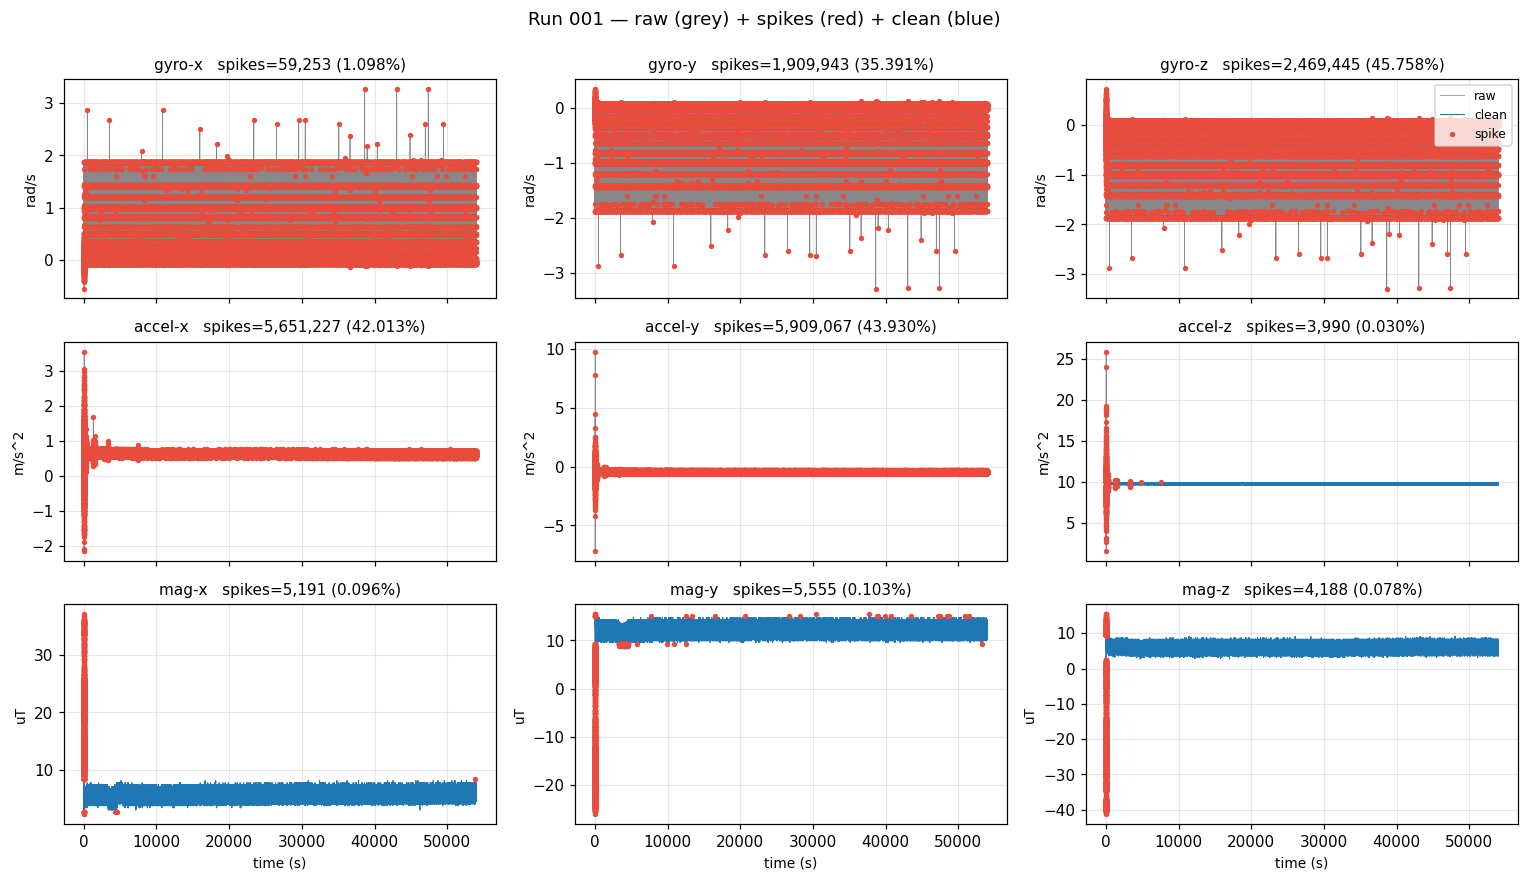

/tmp/ipykernel_28655/2832419179.py:90: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(med - 4 * sigma_ref, med + 4 * sigma_ref)


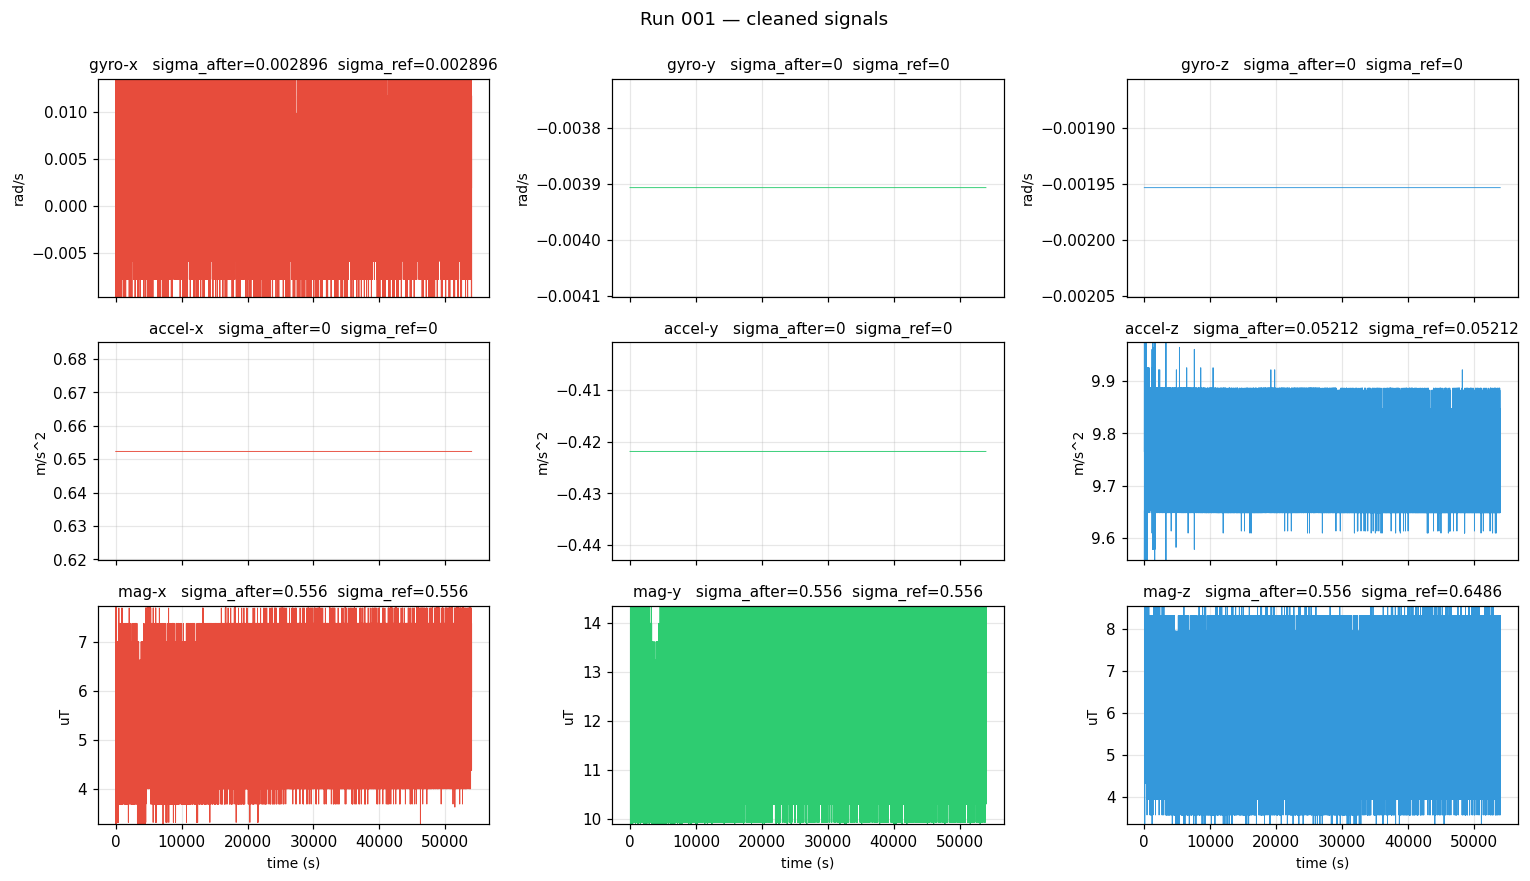


  Run 001 done — memory released.



In [12]:
process_run('001')

  Processing Run 008   (/content/drive/MyDrive/capstone_data/UNIT_0001_RUN_008)


/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: divide by zero encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: invalid value encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: divide by zero encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: invalid value encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: divide by zero encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: invalid value encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: divide by zero encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: invalid value encountered in divide
  z = centered / sigma_ref



  sensor axis     spikes    spike%          bias   sigma_after
  ------------------------------------------------------------
  gyro   x        59,866    1.109%        0.0020      0.002896
  gyro   y     2,098,041   38.880%       -0.0039      0.000000
  gyro   z     2,677,483   49.617%       -0.0020      0.000000
  accel  x     5,647,559   42.542%        0.4609      0.000000
  accel  y     5,693,764   42.890%       -0.1523      0.000000
  accel  z             1    0.000%       -0.0444      0.052122
  mag    x             1    0.000%       18.0625      0.555975
  mag    y             9    0.000%      -16.9375      0.555975
  mag    z             2    0.000%        2.0000      0.648637


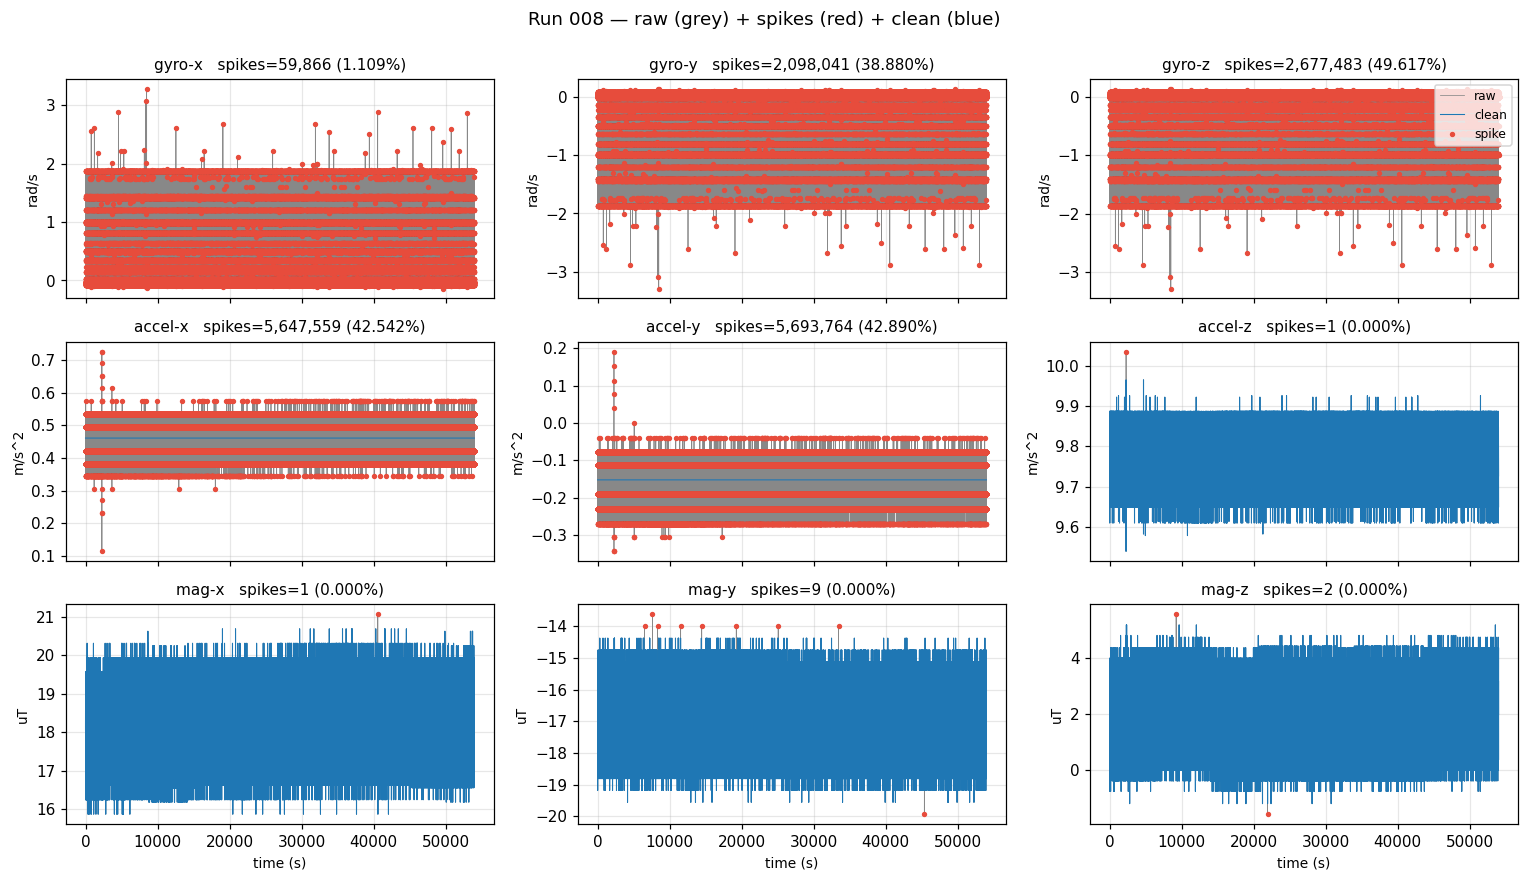

/tmp/ipykernel_28655/2832419179.py:90: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(med - 4 * sigma_ref, med + 4 * sigma_ref)


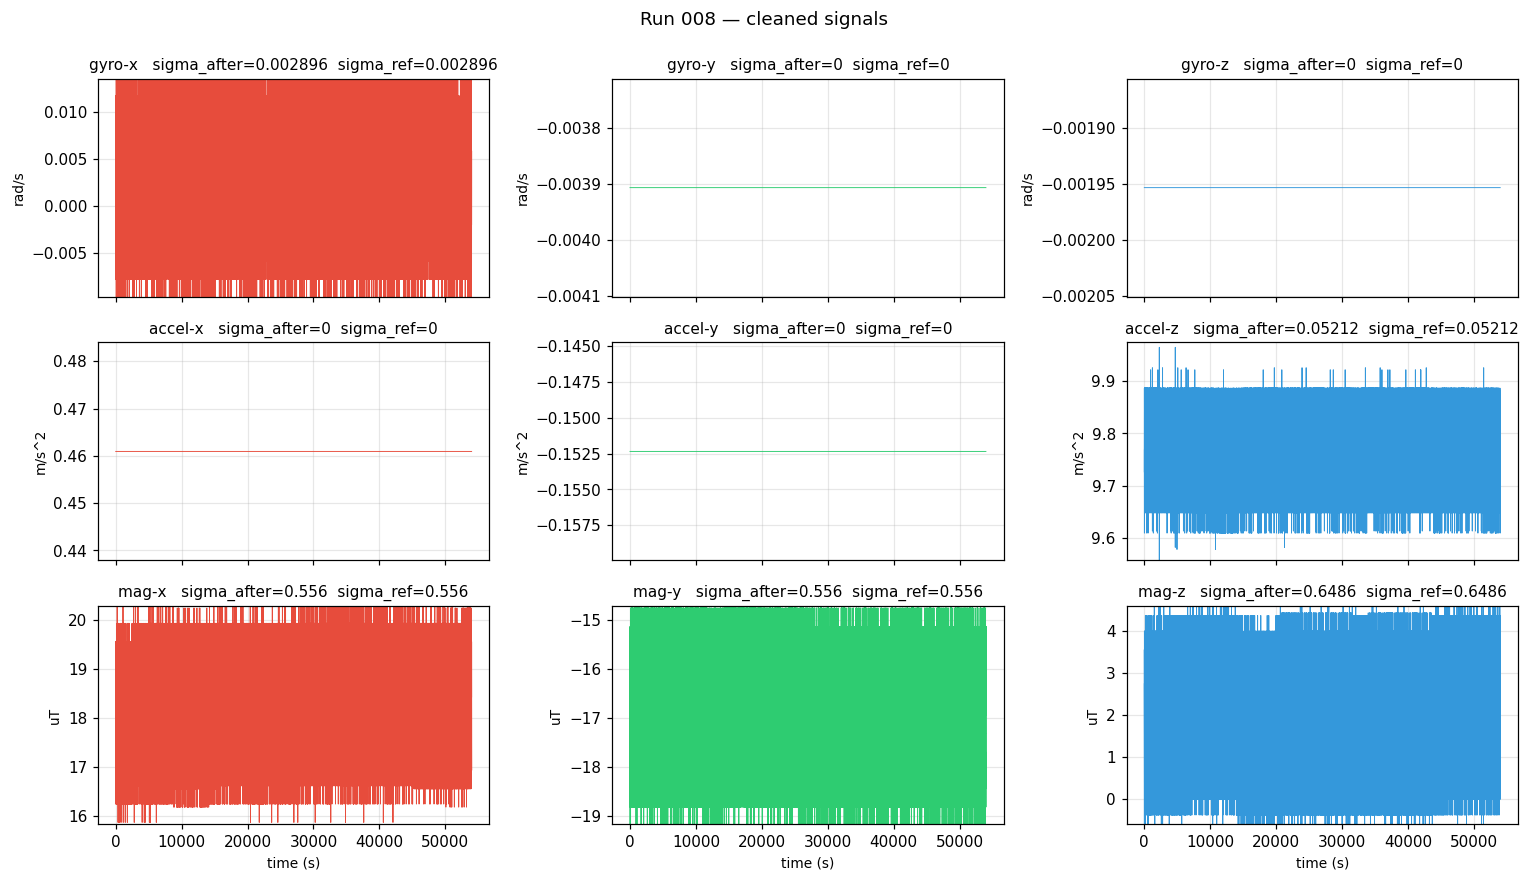


  Run 008 done — memory released.



In [13]:
process_run('008')

  Processing Run 009   (/content/drive/MyDrive/capstone_data/UNIT_0001_RUN_009)


/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: divide by zero encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: invalid value encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: divide by zero encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: invalid value encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: divide by zero encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: invalid value encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: divide by zero encountered in divide
  z = centered / sigma_ref
/tmp/ipykernel_28655/2832419179.py:30: RuntimeWarning: invalid value encountered in divide
  z = centered / sigma_ref



  sensor axis     spikes    spike%          bias   sigma_after
  ------------------------------------------------------------
  gyro   x        56,938    1.055%        0.0020      0.002896
  gyro   y     3,115,116   57.725%       -0.0039      0.000000
  gyro   z     2,685,819   49.770%       -0.0020      0.000000
  accel  x     7,187,809   53.352%        0.4609      0.000000
  accel  y     7,437,538   55.205%       -0.1523      0.000000
  accel  z           186    0.001%       -0.0444      0.052122
  mag    x            13    0.000%       18.8125      0.555975
  mag    y             8    0.000%      -17.0000      0.555975
  mag    z             3    0.000%        1.5625      0.555975


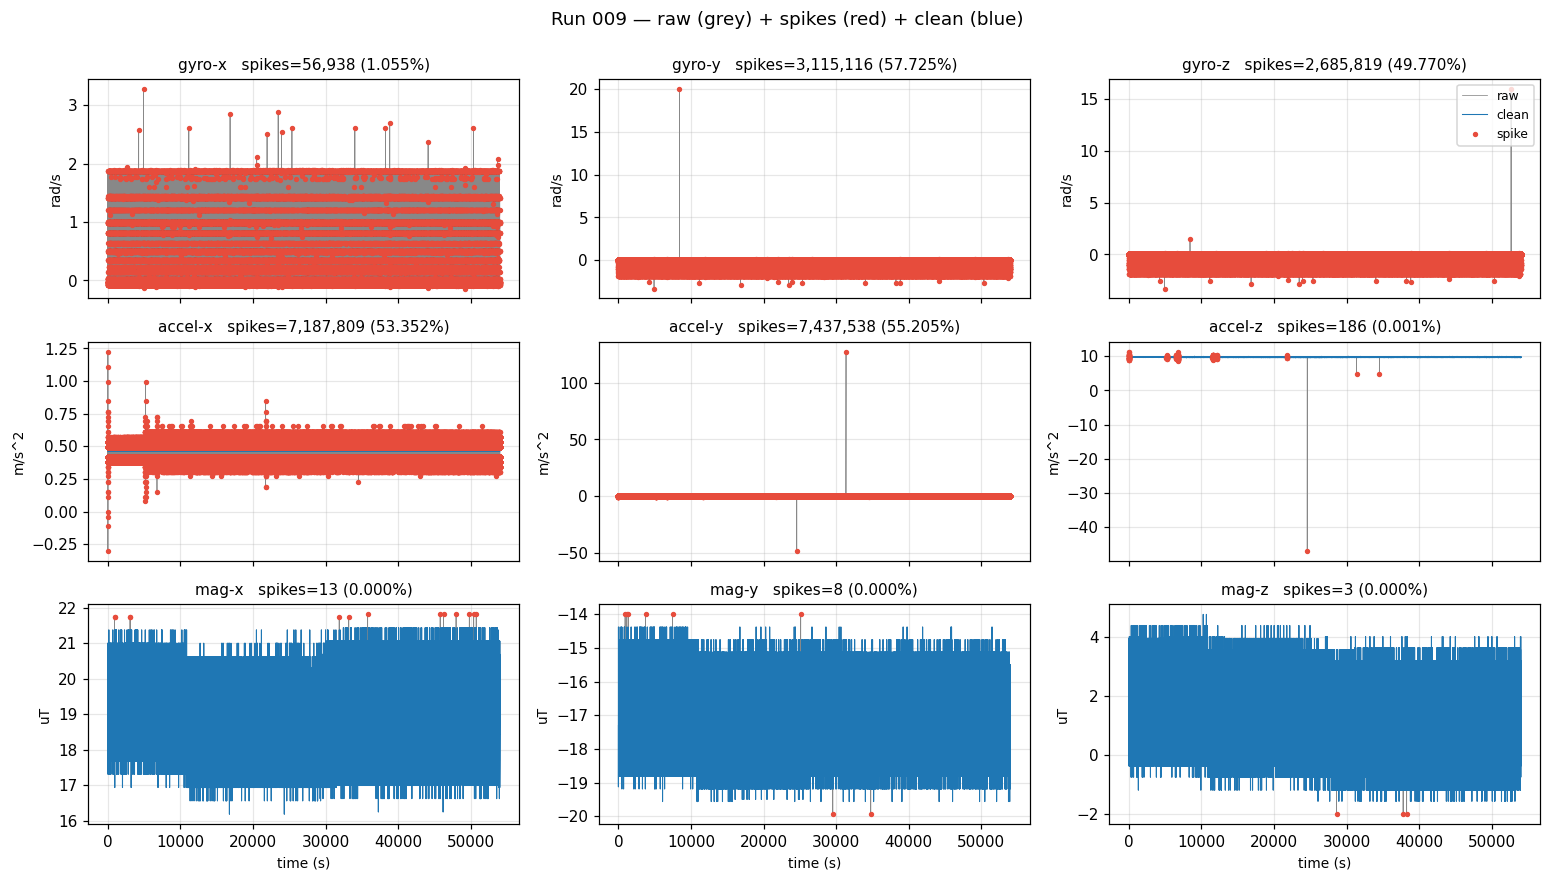

/tmp/ipykernel_28655/2832419179.py:90: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(med - 4 * sigma_ref, med + 4 * sigma_ref)


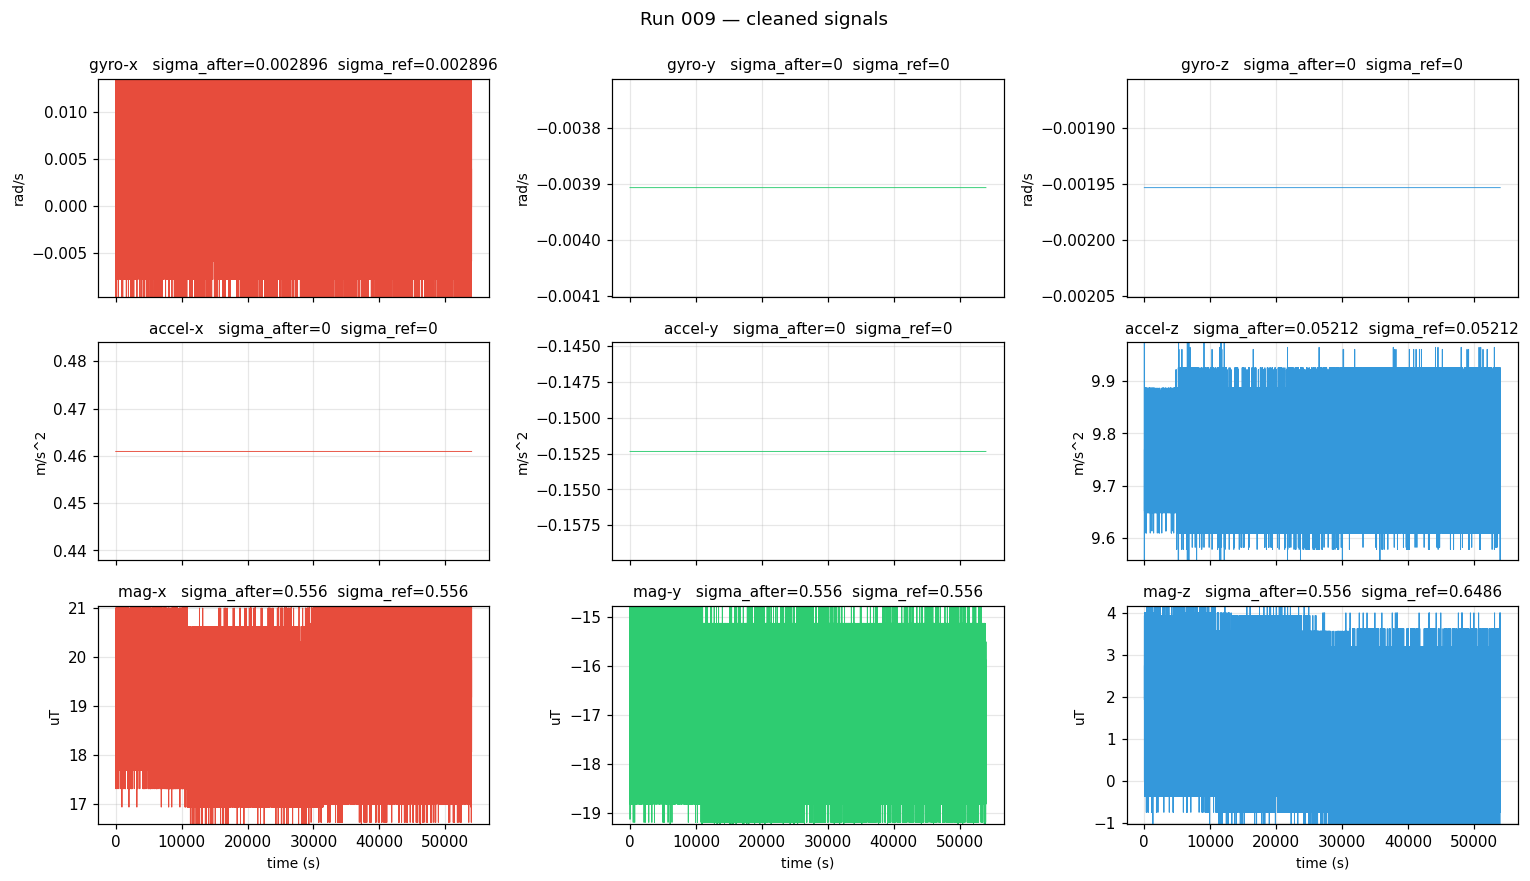


  Run 009 done — memory released.



In [14]:
process_run('009')

  Processing Run 0011   (/content/drive/MyDrive/capstone_data/UNIT_0001_RUN_0011)
    [skip] gyro  not found
    [skip] accel not found
    [skip] mag   not found

  sensor axis     spikes    spike%          bias   sigma_after
  ------------------------------------------------------------
  gyro   x        56,938    1.055%        0.0020      0.002896
  gyro   y     3,115,116   57.725%       -0.0039      0.000000
  gyro   z     2,685,819   49.770%       -0.0020      0.000000
  accel  x     7,187,809   53.352%        0.4609      0.000000
  accel  y     7,437,538   55.205%       -0.1523      0.000000
  accel  z           186    0.001%       -0.0444      0.052122
  mag    x            13    0.000%       18.8125      0.555975
  mag    y             8    0.000%      -17.0000      0.555975
  mag    z             3    0.000%        1.5625      0.555975


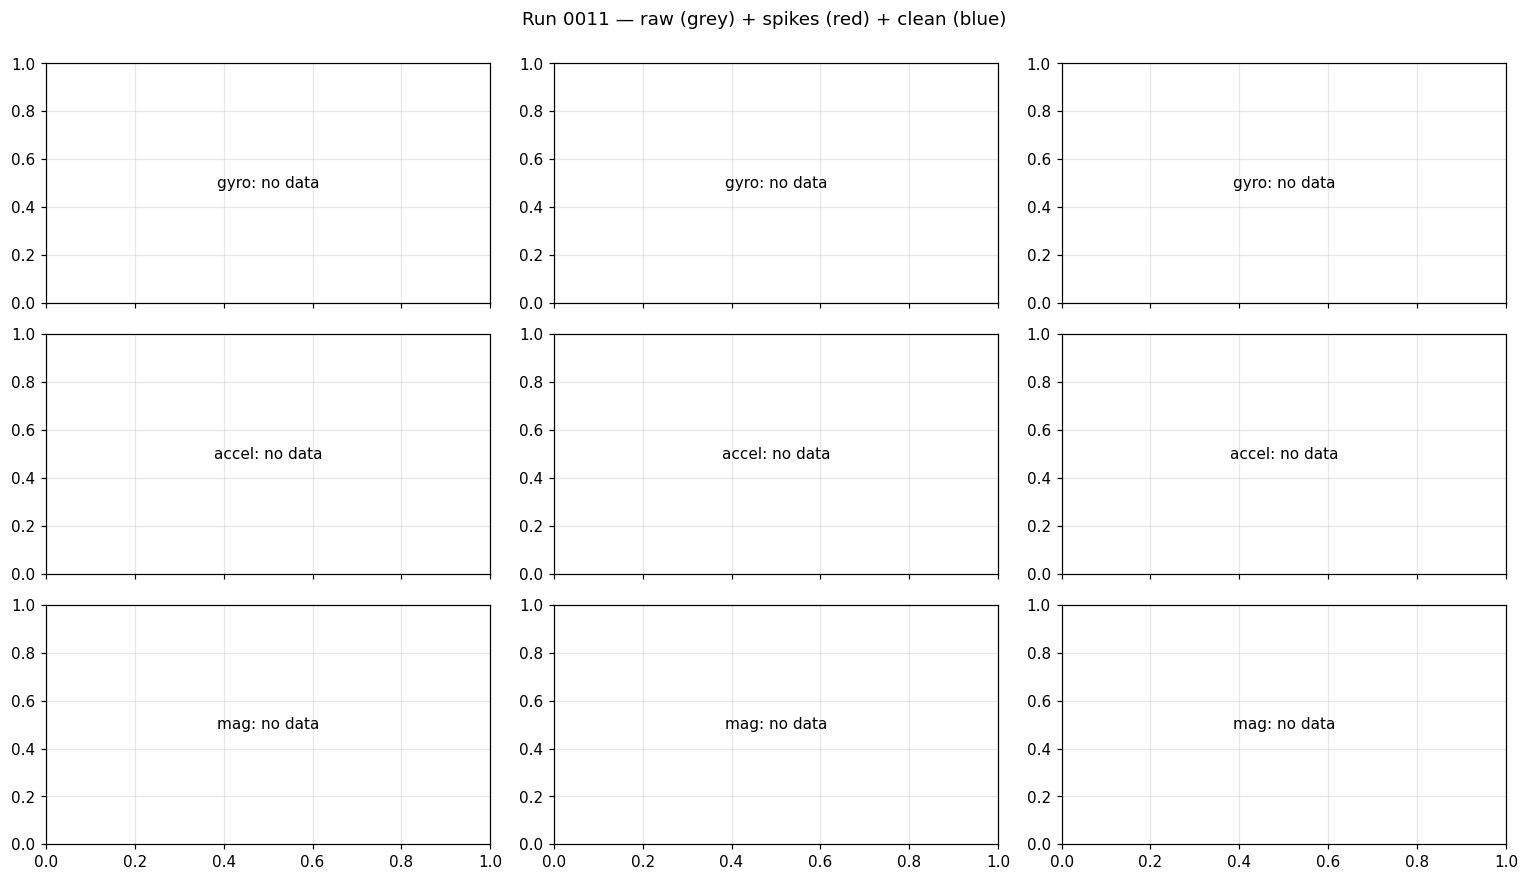

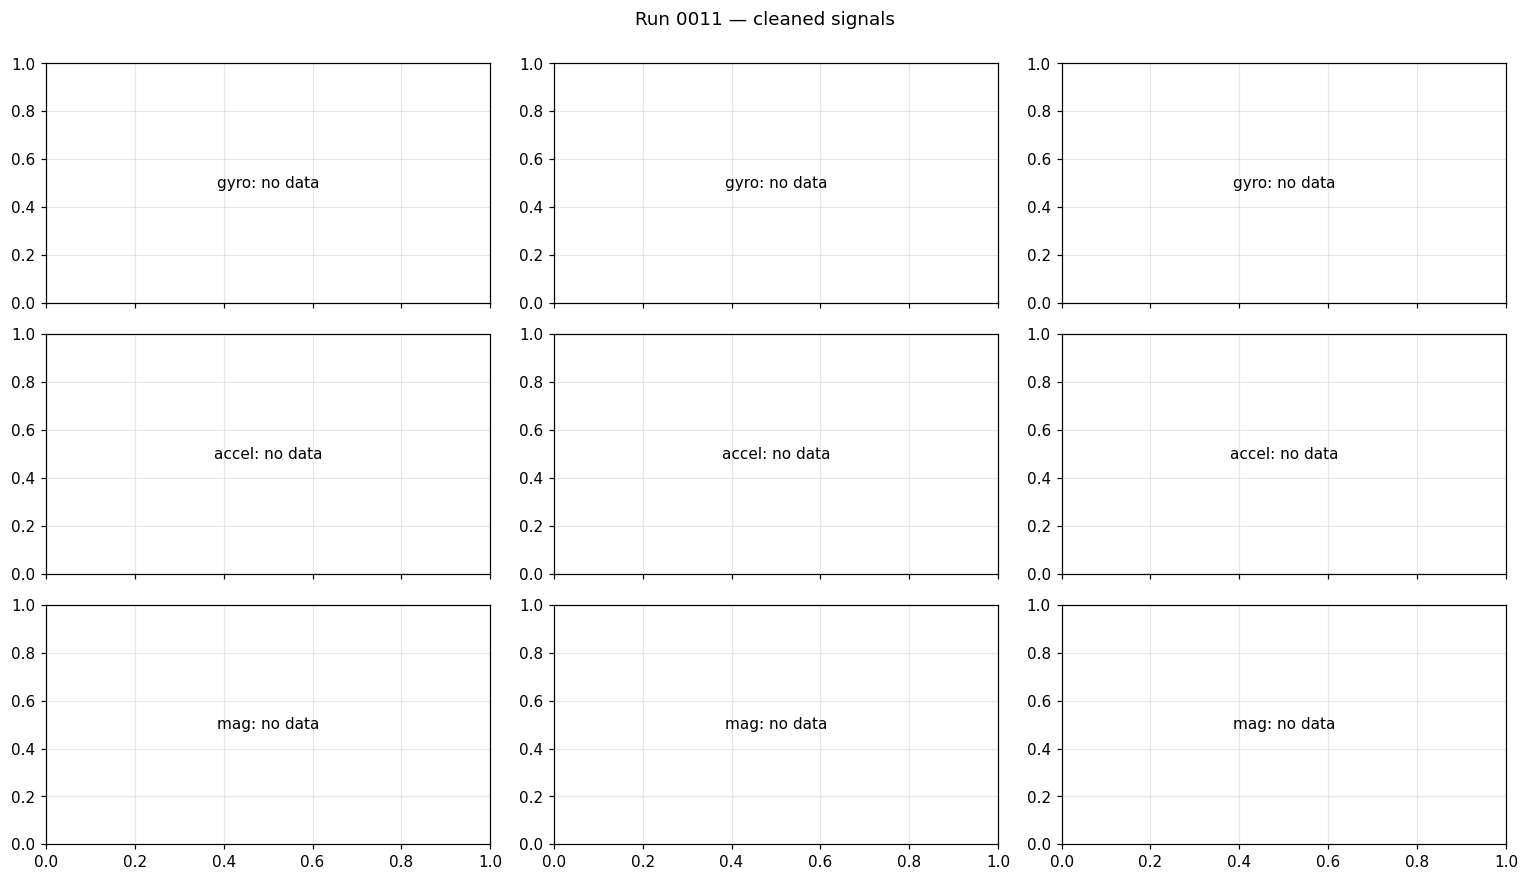

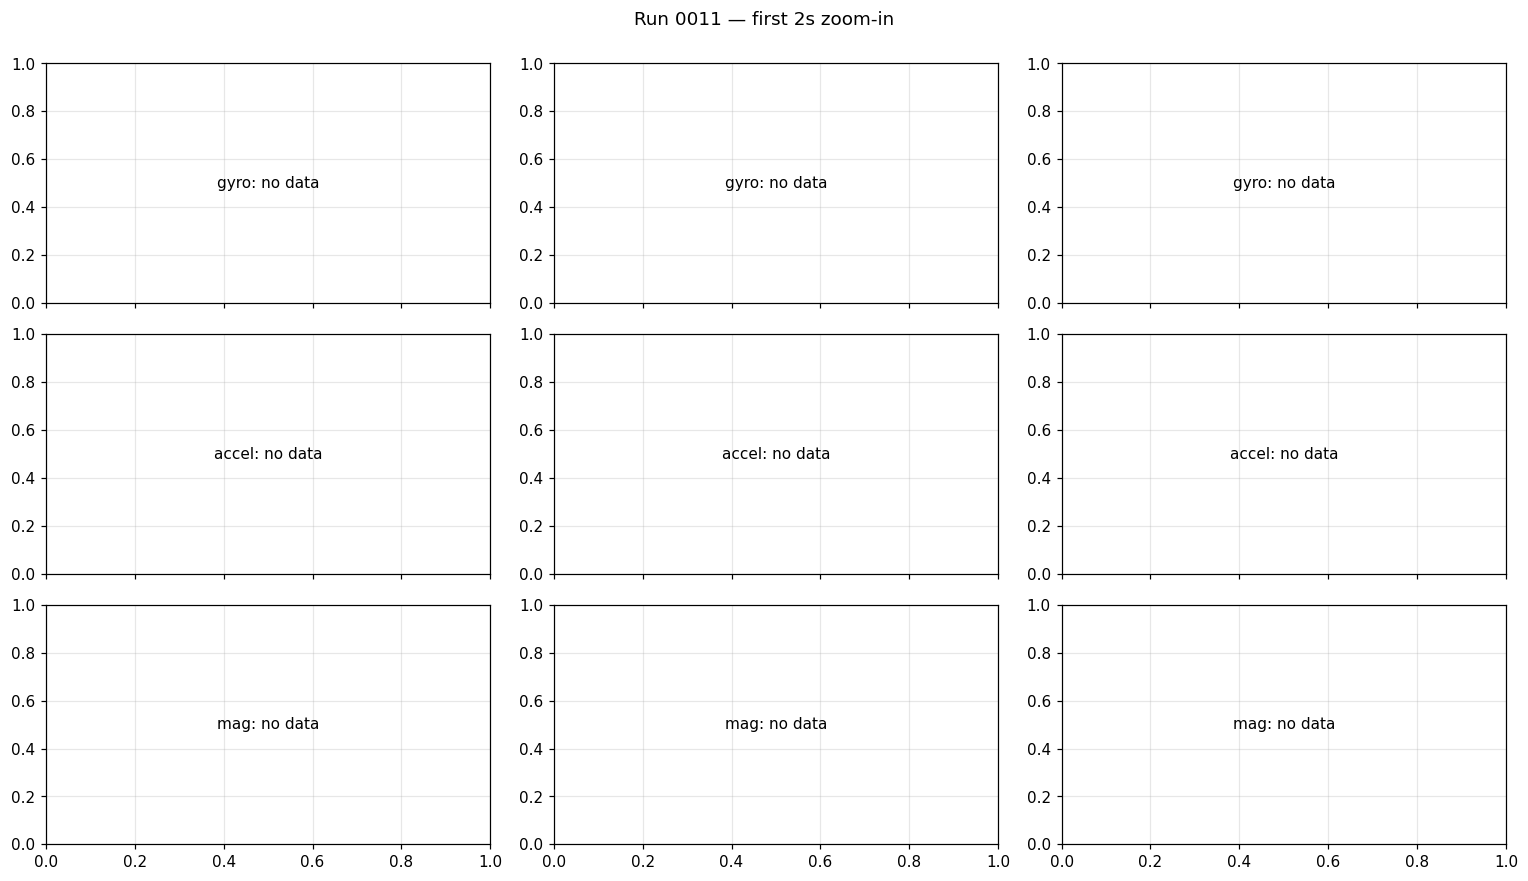


  Run 0011 done — memory released.



In [15]:
process_run('0011')

  Processing Run 0012   (/content/drive/MyDrive/capstone_data/UNIT_0001_RUN_0012)
    [skip] gyro  not found
    [skip] accel not found
    [skip] mag   not found

  sensor axis     spikes    spike%          bias   sigma_after
  ------------------------------------------------------------
  gyro   x        56,938    1.055%        0.0020      0.002896
  gyro   y     3,115,116   57.725%       -0.0039      0.000000
  gyro   z     2,685,819   49.770%       -0.0020      0.000000
  accel  x     7,187,809   53.352%        0.4609      0.000000
  accel  y     7,437,538   55.205%       -0.1523      0.000000
  accel  z           186    0.001%       -0.0444      0.052122
  mag    x            13    0.000%       18.8125      0.555975
  mag    y             8    0.000%      -17.0000      0.555975
  mag    z             3    0.000%        1.5625      0.555975


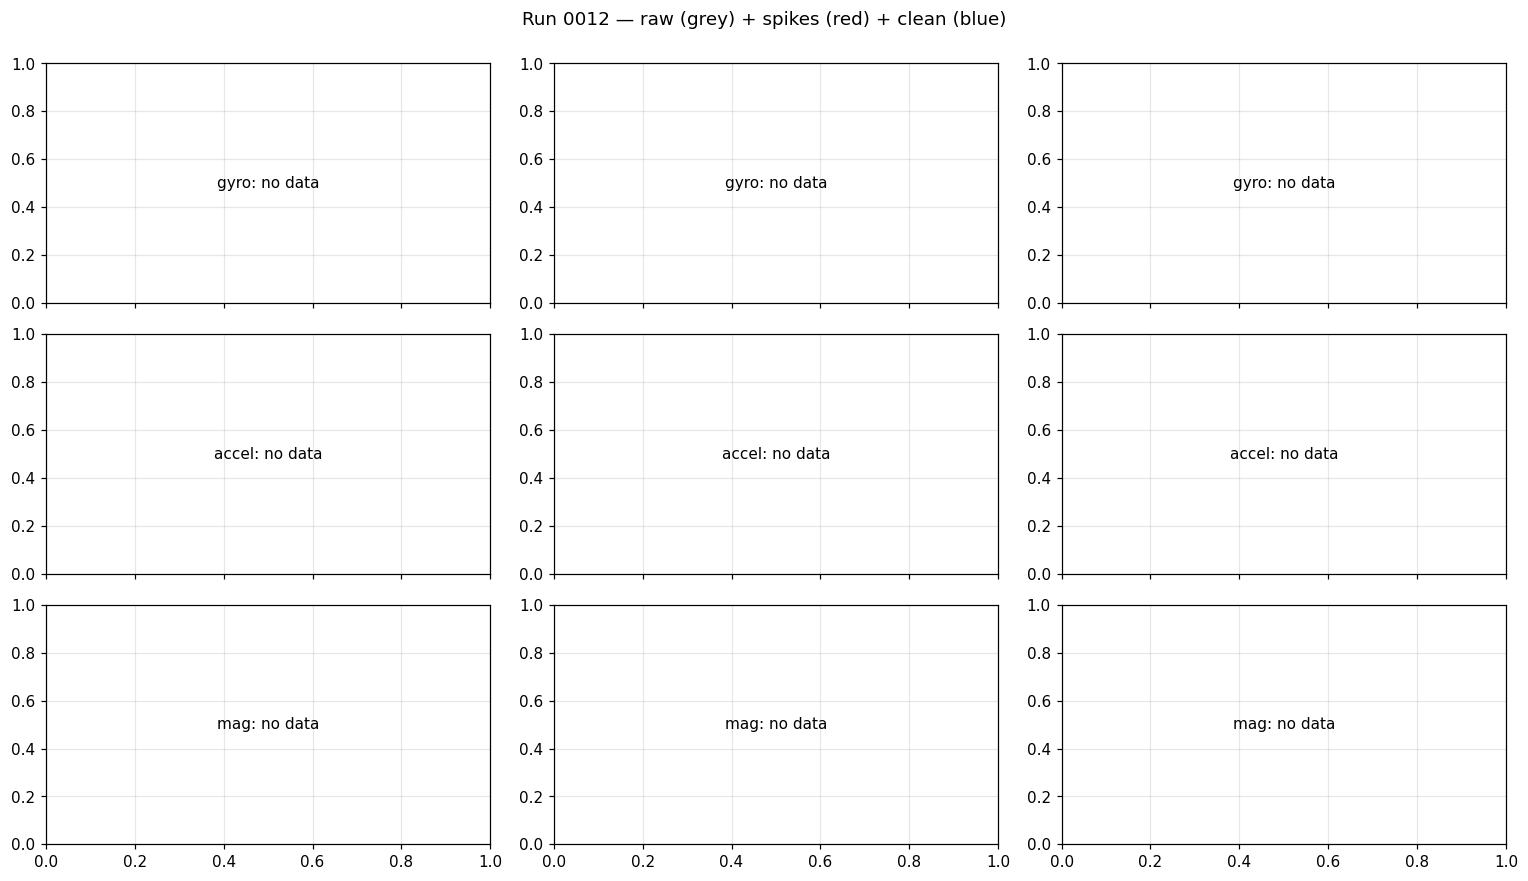

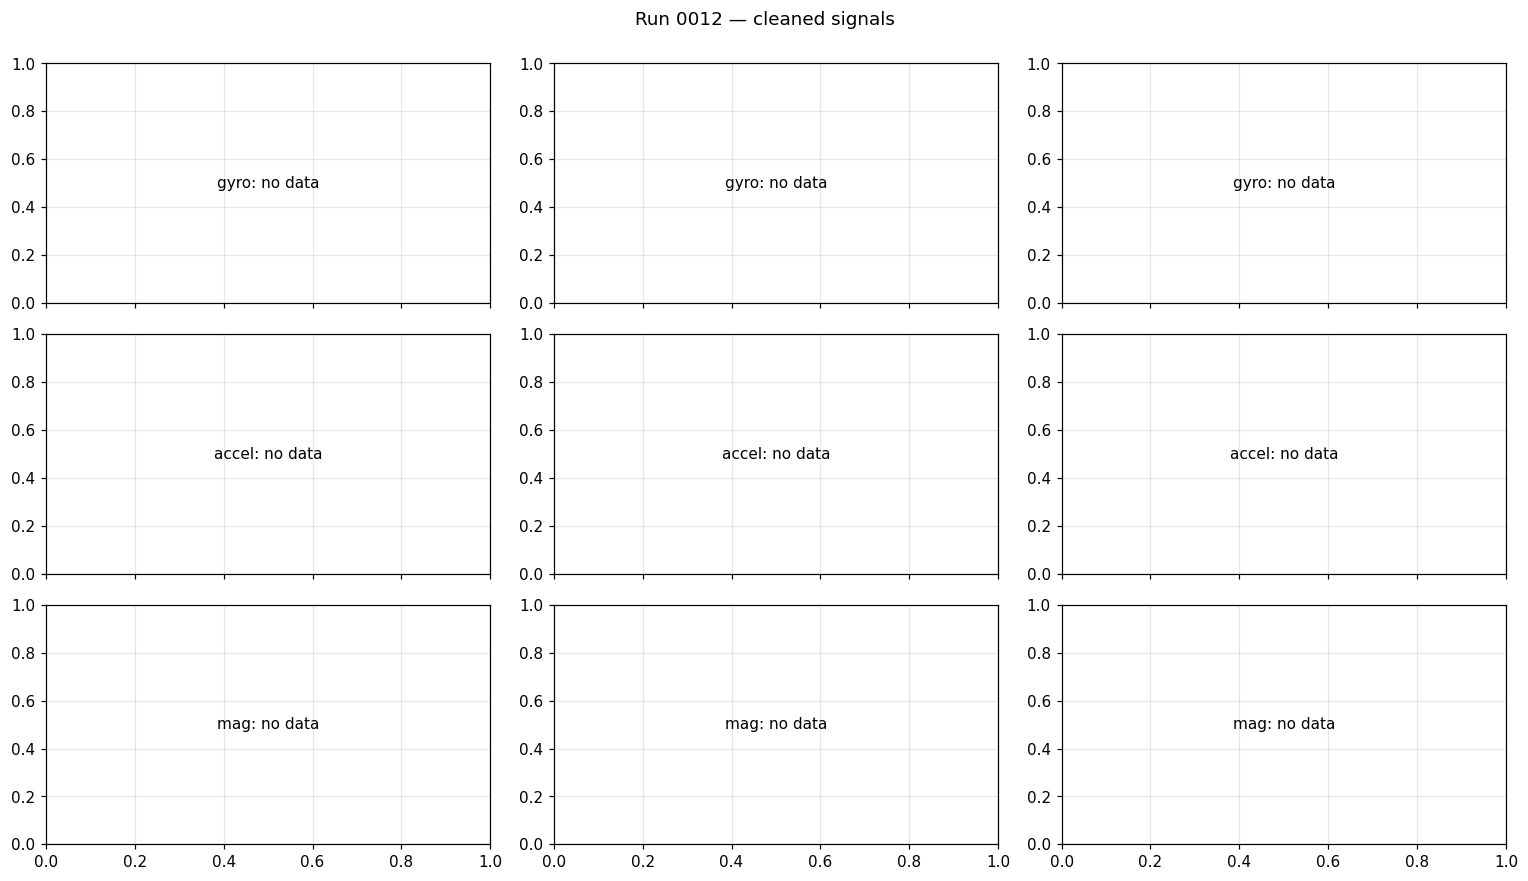


  Run 0012 done — memory released.



In [16]:
process_run('0012')